In [6]:
# Model 1 — Delivery Delay Predictor
## Predicting whether an order will be delivered late

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
print("All imports successful")

All imports successful


In [8]:
## Step 1 — Load Data from Warehouse

In [10]:
BASE_DIR = Path().resolve().parent
conn = duckdb.connect(str(BASE_DIR / "data/warehouse/olist.duckdb"))

df = conn.execute("""
    SELECT
        f.order_id,
        f.is_late,
        f.total_price,
        f.total_freight,
        f.item_count,
        f.review_score,
        f.customer_state,
        s.seller_state,
        p.product_category_name_english AS category,
        p.product_weight_g,
        p.product_length_cm,
        p.product_height_cm,
        p.product_width_cm,
        pay.payment_type,
        pay.payment_installments,
        EXTRACT('month' FROM f.order_purchase_timestamp) AS order_month,
        EXTRACT('hour' FROM f.order_purchase_timestamp) AS order_hour,
        EXTRACT('dayofweek' FROM f.order_purchase_timestamp) AS order_dayofweek
    FROM fact_orders f
    LEFT JOIN dim_seller s ON f.seller_id = s.seller_id
    LEFT JOIN dim_product p ON f.product_id = p.product_id
    LEFT JOIN dim_payment pay ON f.order_id = pay.order_id
    WHERE f.is_late IS NOT NULL
    AND f.order_status = 'delivered'
""").df()

conn.close()

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df["is_late"].value_counts())
print(f"\nLate delivery rate: {df['is_late'].mean()*100:.2f}%")

Dataset shape: (100176, 18)

Target distribution:
is_late
0    92093
1     8083
Name: count, dtype: int64

Late delivery rate: 8.07%


In [11]:
## Step 2 — Feature Engineering

In [12]:
# Drop rows where target or critical features are missing
df = df.dropna(subset=["is_late", "customer_state", "payment_type"])

# Fill numeric nulls with median
numeric_cols = [
    "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm",
    "review_score", "payment_installments"
]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical nulls with unknown
cat_cols = ["seller_state", "category"]
for col in cat_cols:
    df[col] = df[col].fillna("unknown")

# Feature: product volume
df["product_volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

# Feature: freight ratio — how much of order value is freight
df["freight_ratio"] = df["total_freight"] / (df["total_price"] + 1)

# Feature: is same state — seller and customer in same state
df["is_same_state"] = (df["customer_state"] == df["seller_state"]).astype(int)

# Encode categorical columns
le = LabelEncoder()
for col in ["customer_state", "seller_state", "category", "payment_type"]:
    df[col] = le.fit_transform(df[col].astype(str))

print("Feature engineering complete")
print(f"Final dataset shape: {df.shape}")
print(f"\nFeatures created:")
print("  - product_volume_cm3")
print("  - freight_ratio")
print("  - is_same_state")

Feature engineering complete
Final dataset shape: (100175, 21)

Features created:
  - product_volume_cm3
  - freight_ratio
  - is_same_state


In [13]:
## Step 3 — Train/Test Split

In [14]:
# Define features and target
FEATURES = [
    "total_price", "total_freight", "item_count",
    "product_weight_g", "product_volume_cm3",
    "freight_ratio", "is_same_state",
    "customer_state", "seller_state", "category",
    "payment_type", "payment_installments",
    "order_month", "order_hour", "order_dayofweek"
]

TARGET = "is_late"

X = df[FEATURES]
y = df[TARGET]

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps same class ratio in both splits
)

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set   : (80140, 15)
Test set       : (20035, 15)

Class distribution in training set:
is_late
0    73674
1     6466
Name: count, dtype: int64


In [15]:
## Step 4 — Train 3 Models

In [16]:
# Model 1 — Logistic Regression (baseline)
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"  # handles class imbalance
    ))
])

# Model 2 — Random Forest
pipe_rf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Model 3 — XGBoost
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
pipe_xgb = Pipeline([
    ("model", XGBClassifier(
        n_estimators=100,
        random_state=42,
        scale_pos_weight=scale_pos_weight,  # handles class imbalance
        eval_metric="logloss",
        verbosity=0
    ))
])

# Train all 3
print("Training Logistic Regression...")
pipe_lr.fit(X_train, y_train)
print("Training Random Forest...")
pipe_rf.fit(X_train, y_train)
print("Training XGBoost...")
pipe_xgb.fit(X_train, y_train)

print("\nAll 3 models trained successfully")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

All 3 models trained successfully


In [17]:
## Step 5 — Evaluate and Compare Models

In [18]:
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": round(report["accuracy"] * 100, 2),
        "Precision": round(report["1"]["precision"] * 100, 2),
        "Recall": round(report["1"]["recall"] * 100, 2),
        "F1 Score": round(report["1"]["f1-score"] * 100, 2),
        "ROC-AUC": round(roc_auc * 100, 2)
    })

results_df = pd.DataFrame(results)
print("=" * 65)
print("MODEL COMPARISON")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     55.72      10.34   58.54     17.58    59.88
      Random Forest     92.15      71.57    4.52      8.50    74.29
            XGBoost     78.50      19.92   55.14     29.27    73.87


In [19]:
## Step 6 — Visualize Results

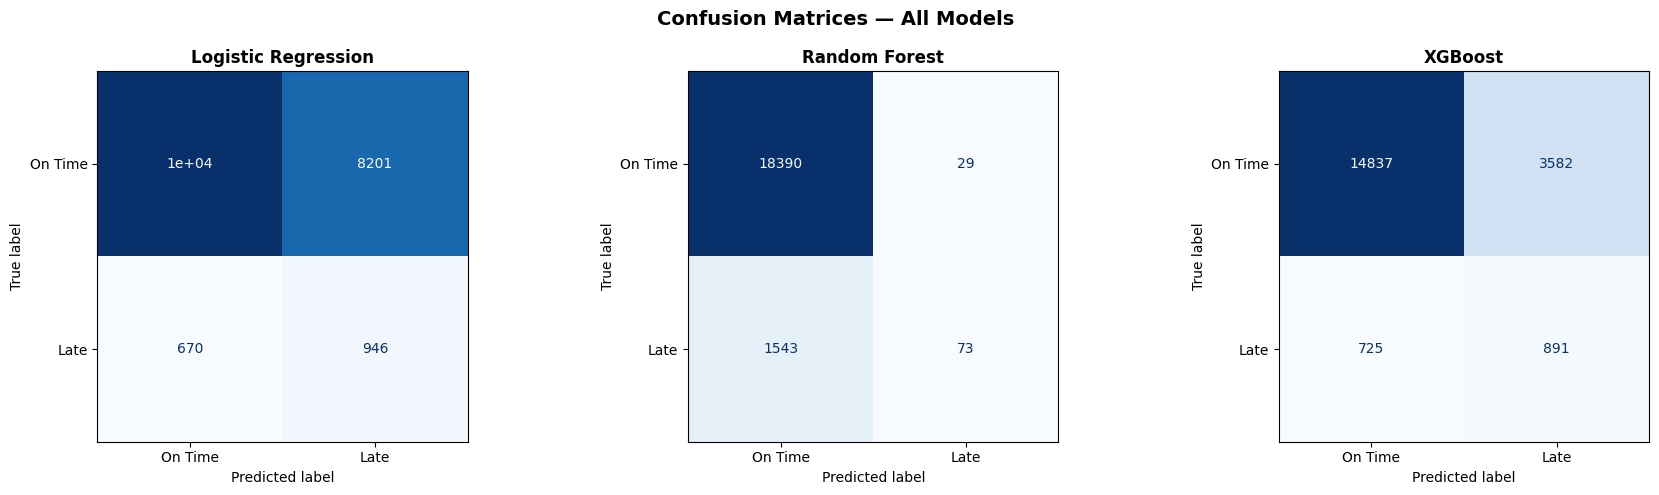

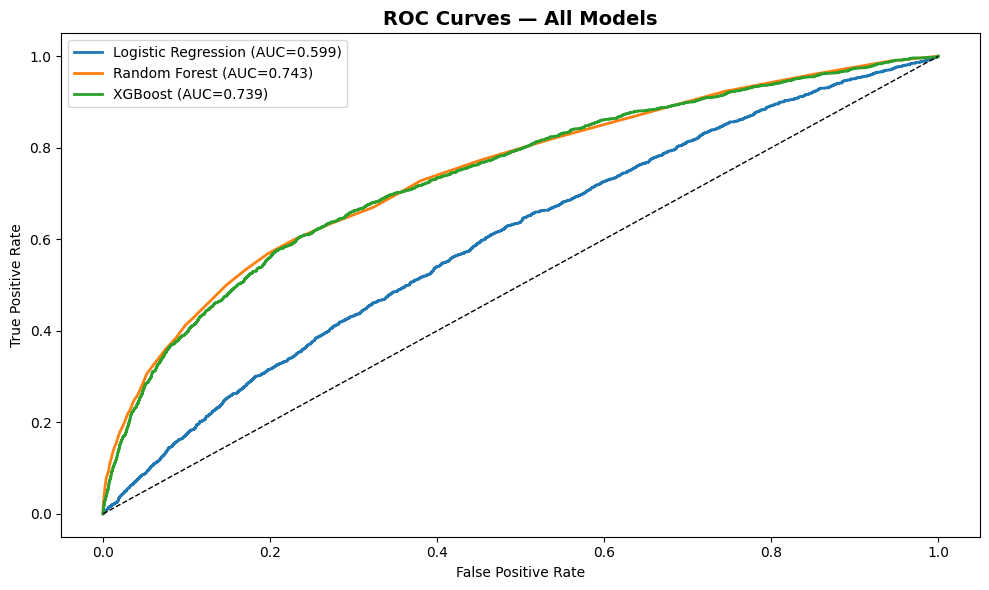

Charts saved


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On Time", "Late"])
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(f"{name}", fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/12_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], "k--", linewidth=1)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/13_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved")

In [21]:
## Step 7 — SHAP Explainability

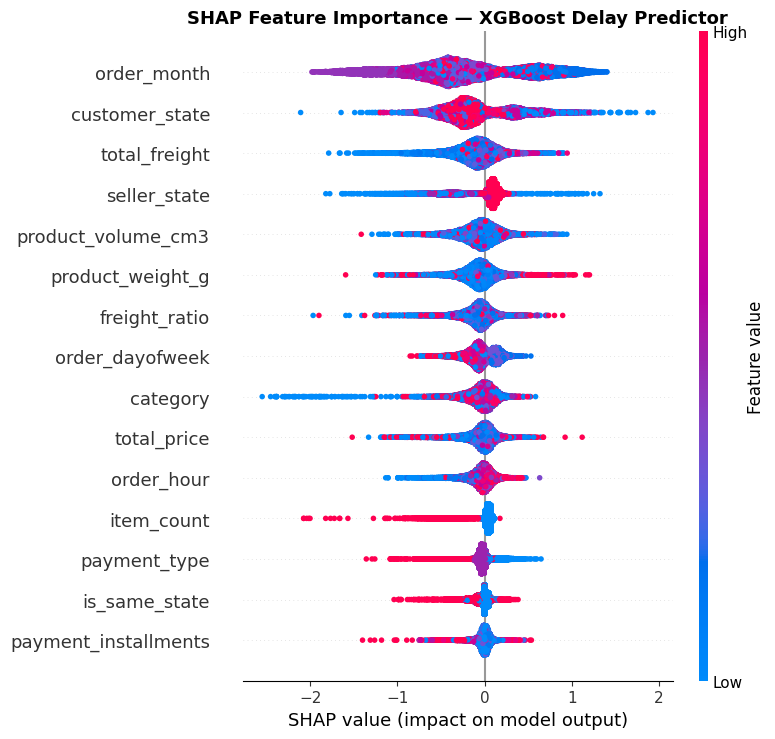

SHAP chart saved


In [22]:
# SHAP works best with XGBoost directly
xgb_model = pipe_xgb.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP Feature Importance — XGBoost Delay Predictor",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/14_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP chart saved")

In [23]:
## Step 8 — Save Best Model

In [24]:
# Create folder to save models
MODELS_DIR = BASE_DIR / "src/ml/saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save XGBoost as it's our best model
joblib.dump(pipe_xgb, MODELS_DIR / "delay_predictor.pkl")

# Save feature list so dashboard knows what features to use
import json
with open(MODELS_DIR / "delay_predictor_features.json", "w") as f:
    json.dump(FEATURES, f)

print(f"Model saved to {MODELS_DIR / 'delay_predictor.pkl'}")
print(f"Features saved to {MODELS_DIR / 'delay_predictor_features.json'}")

# Verify it loads correctly
loaded_model = joblib.load(MODELS_DIR / "delay_predictor.pkl")
test_pred = loaded_model.predict(X_test[:5])
print(f"\nVerification — first 5 predictions: {test_pred}")
print("Model saved and verified successfully")

Model saved to C:\Users\razin\Projects\olist-360\src\ml\saved_models\delay_predictor.pkl
Features saved to C:\Users\razin\Projects\olist-360\src\ml\saved_models\delay_predictor_features.json

Verification — first 5 predictions: [0 0 1 0 0]
Model saved and verified successfully
